<a href="https://colab.research.google.com/github/Fittx/Machine-Learning---CCMACLRL/blob/main/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [19]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier


import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv('/content/personality_dataset.csv')

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

Display the summary of all the features of the dataset using `.info()`

In [35]:

df = pd.read_csv('/content/personality_dataset.csv')
print(df.head(5))
print(df.info())

   Time_spent_Alone Stage_fear  Social_event_attendance  Going_outside  \
0                 3        Yes                        6              7   
1                 2         No                        8              6   
2                 1         No                        9              4   
3                 8         No                        0              0   
4                 5        Yes                        3              0   

  Drained_after_socializing  Friends_circle_size  Post_frequency Personality  
0                        No                   14               5   Extrovert  
1                        No                    7               8   Extrovert  
2                        No                    9               3   Extrovert  
3                       Yes                    9               3   Introvert  
4                        No                    2               6   Introvert  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data co

Display the total number of samples from each label using `.value_counts()`

In [9]:
label1 = df["Personality"].value_counts()
print(label1)



Personality
Introvert    2502
Extrovert    2498
Name: count, dtype: int64


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Personality'],
      dtype='object')


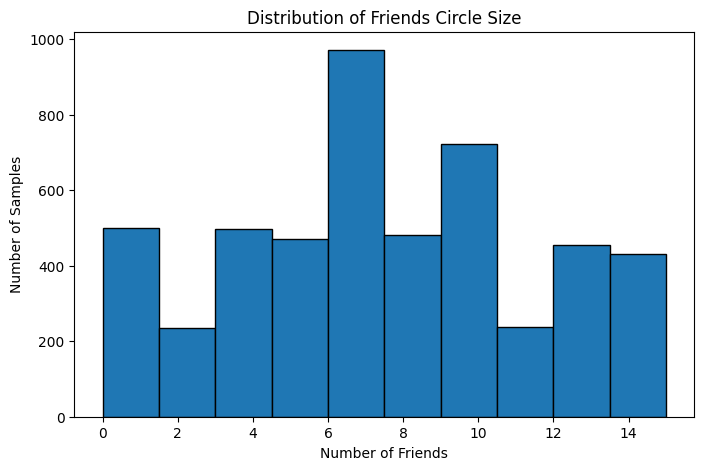

In [10]:
print(df.columns)
plt.figure(figsize=(8,5))

plt.hist(df["Friends_circle_size"], bins=10, edgecolor='black')

plt.title("Distribution of Friends Circle Size")
plt.xlabel("Number of Friends")
plt.ylabel("Number of Samples")

plt.show()

Remove the name column using `drop()` method

In [34]:
df = df.drop(columns=["Name"], errors="ignore")

## C. Split the dataset into training and test set

In [37]:
df["Stage_fear"] = df["Stage_fear"].map({"Yes": 1, "No": 0})
df["Drained_after_socializing"] = df["Drained_after_socializing"].map({"Yes": 1, "No": 0})
df["Personality"] = df["Personality"].map({"Introvert": 0, "Extrovert": 1})

Convert the features into an numpy array using .values() and store it in a variable "X"

In [38]:
X = df.drop("Personality", axis=1).values

Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [39]:
y = df["Personality"].values

Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Display the dimensions of each variables using `.shape()`

In [42]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4000, 7)
X_test: (1000, 7)
y_train: (4000,)
y_test: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [43]:
knn = KNeighborsClassifier(n_neighbors=5)

Train the model using the `.fit()`

In [45]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

Test the model using the `.predict()`

In [46]:
y_pred = knn.predict(X_test)

## E. Evaluate the model

Create a confusion matrix

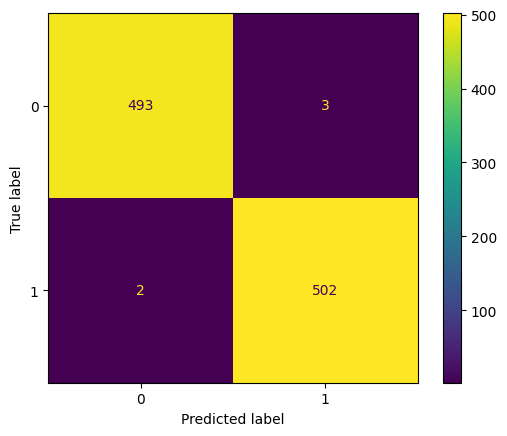

In [47]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

Display the accuracy

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.995


Display the precision

In [49]:
print("Precision:", precision_score(y_test, y_pred))

Precision: 0.994059405940594


Display the recall

In [50]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.996031746031746


Display the f1-score

In [51]:
print("F1-score:", f1_score(y_test, y_pred))

F1-score: 0.9950445986124876


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [52]:
my_data = [[
    4,  # Time_spent_Alone
    0,  # Stage_fear (No=0, Yes=1)
    6,  # Social_event_attendance
    5,  # Going_outside
    1,  # Drained_after_socializing (Yes=1, No=0)
    8,  # Friends_circle_size
    3   # Post_frequency
]]

prediction = knn.predict(my_data)

if prediction[0] == 0:
    print("Predicted Personality: Introvert")
else:
    print("Predicted Personality: Extrovert")

Predicted Personality: Extrovert
